#### Model Training - YOLOv5n with COCO pretrained weights (transfer learning, no froze layers)

In [51]:
import os
import sys
import yaml
import subprocess
from pathlib import Path
import psutil
import mlflow
import mlflow.pytorch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [ ]:
# SEED, train/val/test, early stopping, epochs = 100-200
# image resizing, fix the training class
# structure the data.yaml file 
# clone the YOLOv5 (coco pretrained weights), 
# enable requires_grad to freeze the early layers,
# Pre-training check
# YOLOv5 architecture: 
    # backbone (0-9 layers responsible fro feature extraction) --> learn the structure of low level visual features (edges, texture, curves)
    # heads (the remaining layers which performs object detection)
# YOLOv5 freezing options: (control each layers are frozen using --freeze argument) `cmd`
    # Freeze backbone only (0-9) -- common fro adapting the model to a specific niche task (the datasets should shares the same low-level visual features) 
    # Freeze all except final detection layers (0-24) -- freeze the entire network, leaving only the final output convolution layers (Detect model `24` in YOLOv5) 
            #  -- useful when primarily need to adjust the model for a diff number of output classes while keeping the vast majority of learned features.
# load the best model, output dir,  

In [12]:
SEED = 42

# Paths
PROJECT_ROOT = Path.cwd().parent
YOLOV5_DIR = PROJECT_ROOT / 'model' / 'yolov5'
DATA_YAML = PROJECT_ROOT / 'data' / 'data.yaml'
RUN_DIR = PROJECT_ROOT / 'model' / 'train'

# Training Hyperparameters
IMG_SIZE = 640
BATCH_SIZE = 16 #safe for 16GB RAM/CPU training
EPOCHS = 100
PATIENCE = 20 # early stopping
WEIGHTS = 'yolov5n.pt' #COCO pretrained weights
RUN_NAME = 'edge_cctv_v1' # name for this training run

# MLflow
MLFLOW_EXPERIMENT = 'YOLOv5n-CCTV-PersonDetection'

#Recap
print('Project root: ', PROJECT_ROOT)
print('YOLOv5 Dir: ', YOLOV5_DIR)
print('Data YAML: ', DATA_YAML)
print('Weights: ', WEIGHTS)
print(f'Training plan: {EPOCHS} epochs max, batch={BATCH_SIZE}, img={IMG_SIZE}, patience={PATIENCE} ')

Project root:  c:\Users\ASUS\Desktop\EdgeIA_PFE
YOLOv5 Dir:  c:\Users\ASUS\Desktop\EdgeIA_PFE\model\yolov5
Data YAML:  c:\Users\ASUS\Desktop\EdgeIA_PFE\data\data.yaml
Weights:  yolov5n.pt
Training plan: 100 epochs max, batch=16, img=640, patience=20 


#### Step 1: Env Setup

* Clone the YOLOv5 repo and install its dependencies
* YOLOv5 is not a pip package - it is used as a runnable python project `exec cmd with params`

In [13]:
if not YOLOV5_DIR.exists():
    print('Cloning YOLOv5 repo')
    subprocess.run(
        ['git', 'clone', 'https://github.com/ultralytics/yolov5', str(YOLOV5_DIR)],
        check=True
    )
    print('Repo cloned')
else:
    print(f'YOLOv5 is already cloned check, {YOLOV5_DIR} -- skipping')

req_file = YOLOV5_DIR / 'requirements.txt'

#install the required dependencies
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-r', str(req_file), '-q'],
    check=True
)

print('YOLOv5 requirements installed')

Cloning YOLOv5 repo
Repo cloned
YOLOv5 requirements installed


#### Step 2: Pre-training Checks

* verify dataset structure and YAML config before launching training
* verify the available memory for training (if insufficient drop batch size to 8)

In [40]:
# check data.yaml config
assert DATA_YAML.exists(), f'dataset.yaml not fount at {DATA_YAML}'

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

print('data.yaml content:')
print(yaml.dump(cfg, default_flow_style=False))

assert cfg.get('nc') == 1, 'nc must be 1'
assert cfg.get('names') == ['person'], 'names must be ["person"]'
print('data.yaml is valid')

# check split counts
data_root = PROJECT_ROOT / 'data' / 'splits'
expected = {'train': 527, 'val': 150, 'test': 76}

for split, exp_count in expected.items():
    img_dir = data_root / split / 'images'
    lbl_dir = data_root / split / 'labels'

    imgs = len(list(img_dir.glob('*.*')))
    lbls = len(list(lbl_dir.glob('*.txt')))

    status = f'found {imgs}' if imgs == exp_count else f'Error: expected {exp_count}'
    print(f'{split}: {imgs} images | {lbls} labels')

# check available memory for training
ram_gb = psutil.virtual_memory().available / 1e9
print(f'\nAvailable RAM: {ram_gb:.1f} GB')

if ram_gb < 4 :
    print("Low RAM - drop batch size to 8")
else:
    print("RAM looks fine for batch size 16")



data.yaml content:
names:
- person
nc: 1
roboflow:
  license: Private
  project: adams-workspace-q6pek
  url: https://app.roboflow.com/adams-workspace-q6pek/adams-workspace-q6pek/dataset
  version: dataset
  workspace: adams-workspace-q6pek
test: splits/test/images
train: splits/train/images
val: splits/valid/images

data.yaml is valid
train: 527 images | 527 labels
val: 150 images | 150 labels
test: 76 images | 76 labels

Available RAM: 4.2 GB
RAM looks fine for batch size 16


#### Step 3: MLflow - Experiment setup

* Mlflow tracks all training runs: hyper params, metrics per epoch, and output artifacts. 
* Each run is stored `mlruns/` at the project root and can be visualised with mlflow ui.

In [37]:
#set mlflow tracking URI (locally)

mlflow.set_tracking_uri(f'../mlruns')
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print(f'MLflow experiment: {MLFLOW_EXPERIMENT}')
print(f'Tracking folder   : {PROJECT_ROOT}/mlruns')
print('\nTo view the UI, run in a terminal:')
print(f'  cd {PROJECT_ROOT} && mlflow ui')
print('  Then open http://localhost:5000')

MLflow experiment: YOLOv5n-CCTV-PersonDetection
Tracking folder   : c:\Users\ASUS\Desktop\EdgeIA_PFE/mlruns

To view the UI, run in a terminal:
  cd c:\Users\ASUS\Desktop\EdgeIA_PFE && mlflow ui
  Then open http://localhost:5000


#### step 4: Training Launch YOLOv5n
* calling `train.py` from the YOLOv5 repo as a subprocess.
* YOLOv5 support MLflow logging - no manual metric logging needed

In [ ]:
# enable Mlflow logging inside YOLOv5
# YOLOv5 detects this enc variable and logos to the active MLflow experiment.
os.environ['MLFLOW_TRACKING_URI'] = '../mlruns'

# transfer learning training params
train_cmd = [
    sys.executable, str(YOLOV5_DIR / 'train.py'),
    '--batch', str(BATCH_SIZE),
    '--weights', WEIGHTS,
    '--data', str(DATA_YAML),
    '--epochs', str(EPOCHS),
    '--img', str(IMG_SIZE),
    '--project', str(RUN_DIR),
    '--name', RUN_NAME,
    '--patience', str(PATIENCE),
    '--seed', str(SEED),
    '--exist-ok'
]

print('Launching training with command:')
print(' '.join(train_cmd))

# the training could takes 2-4h
# the val/mAP@50 should rise over epochs.
# Early stopping triggers if it stalls for 20 epochs
# run training

result = subprocess.run(train_cmd, cwd=str(YOLOV5_DIR))

if result.returncode == 0:
    print('Training completed successfully')
else:
    print(f'Training failed with code {result.returncode}. Check logs')
    print(result.stderr)
    print(result.stdout)

Launching training with command:
c:\Users\ASUS\Desktop\EdgeIA_PFE\venv\Scripts\python.exe c:\Users\ASUS\Desktop\EdgeIA_PFE\model\yolov5\train.py --batch 16 --weights yolov5n.pt --data c:\Users\ASUS\Desktop\EdgeIA_PFE\data\data.yaml --epochs 100 --img 640 --project c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train --name edge_cctv_v1 --patience 20 --seed 42 --exist-ok
Training failed with code 3221225477. Check logs
None
None


In [43]:
# After RAM exhausting we will launch a second run with only 60 epochs abd batch size 8
# We will add worker 0 to avoid crush again
BATCH_SIZE = 8
EPOCHS = 60
RUN_NAME = "edge_cctv_v2"
WORKERS = 0
os.environ['MLFLOW_TRACKING_URI'] = '../mlruns'

# transfer learning training params
train_cmd = [
    sys.executable, str(YOLOV5_DIR / 'train.py'),
    '--batch', str(BATCH_SIZE),
    '--weights', WEIGHTS,
    '--data', str(DATA_YAML),
    '--epochs', str(EPOCHS),
    '--img', str(IMG_SIZE),
    '--project', str(RUN_DIR),
    '--name', str(RUN_NAME),
    '--patience', str(PATIENCE),
    '--seed', str(SEED),
    '--workers', str(WORKERS),
    '--exist-ok'
]

print('Launching training with command:')
print(' '.join(train_cmd))

# the training could takes 2-4h
# the val/mAP@50 should rise over epochs.
# Early stopping triggers if it stalls for 20 epochs
# run training

result = subprocess.run(train_cmd, cwd=str(YOLOV5_DIR))

if result.returncode == 0:
    print('Training completed successfully')
else:
    print(f'Training failed with code {result.returncode}. Check logs')
    print(result.stderr)
    print(result.stdout)

Launching training with command:
c:\Users\ASUS\Desktop\EdgeIA_PFE\venv\Scripts\python.exe c:\Users\ASUS\Desktop\EdgeIA_PFE\model\yolov5\train.py --batch 8 --weights yolov5n.pt --data c:\Users\ASUS\Desktop\EdgeIA_PFE\data\data.yaml --epochs 60 --img 640 --project c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train --name edge_cctv_v2 --patience 20 --seed 42 --workers 0 --exist-ok
Training completed successfully


### step 5: Training curves
* plot the training and validation losses + mAP over epochs from `results.csv`
    * Box loss / obj loss / cls loss
    * val/mAP@50 plot
    * best epoch

In [46]:
run_dir = RUN_DIR / RUN_NAME
csv_file = run_dir / 'results.csv'
best_pt = run_dir / 'weights' / 'best_pt'
last_pt = run_dir / 'weights' / 'last.pt'

df = pd.read_csv(csv_file)
df.columns = df.columns.str.strip()  # YOLOv5 adds whitespace to column names

print('Columns found:', list(df.columns))
print(f'Epochs recorded: {len(df)}')
df.tail(5)

Columns found: ['epoch', 'train/box_loss', 'train/obj_loss', 'train/cls_loss', 'metrics/precision', 'metrics/recall', 'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', 'val/box_loss', 'val/obj_loss', 'val/cls_loss', 'x/lr0', 'x/lr1', 'x/lr2']
Epochs recorded: 60


,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
55,55,0.025281,0.059056,0,0.88004,0.86233,0.93204,0.67367,0.023510,0.055661,0,0.001090,0.001090,0.001090
56,56,0.025592,0.062308,0,0.89402,0.85390,0.93527,0.68082,0.023351,0.054827,0,0.000925,0.000925,0.000925
57,57,0.025491,0.060748,0,0.88067,0.86755,0.93546,0.68058,0.023386,0.055039,0,0.000760,0.000760,0.000760
58,58,0.025412,0.059351,0,0.87898,0.85975,0.93298,0.67648,0.023464,0.055362,0,0.000595,0.000595,0.000595
59,59,0.024914,0.058274,0,0.88445,0.86227,0.93402,0.67676,0.023360,0.054979,0,0.000430,0.000430,0.000430


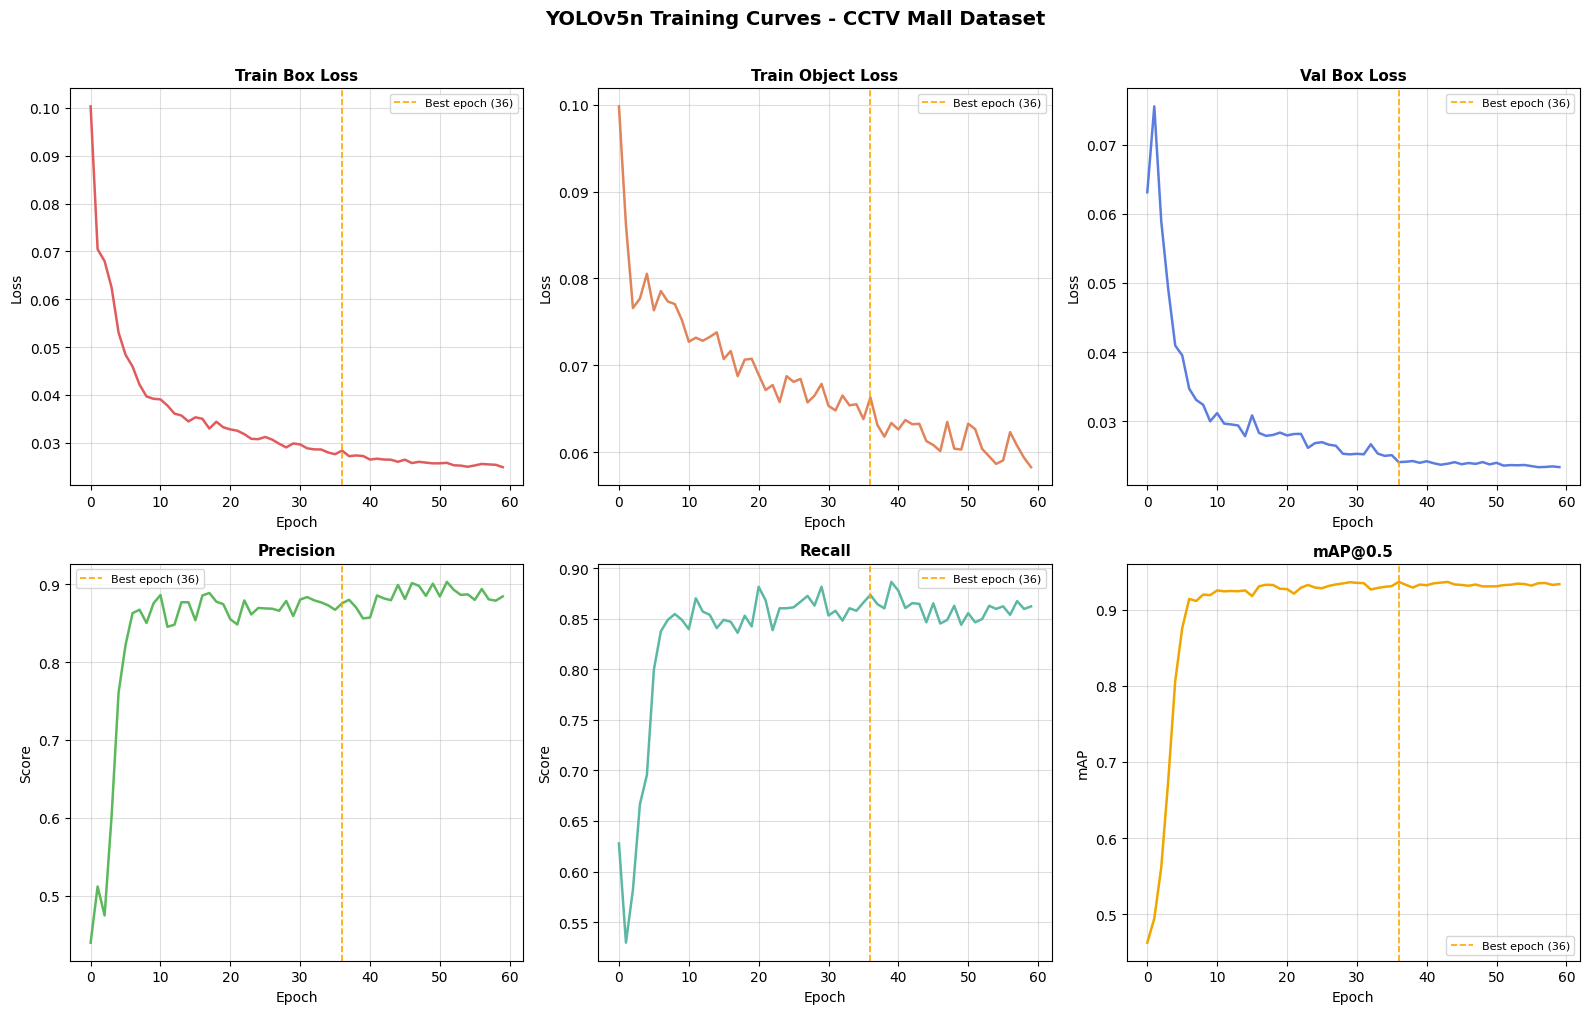


 Best epoch   : 36
Best mAP@0.5 : 0.9370


In [52]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

epochs = df['epoch'] if 'epoch' in df.columns else df.index
map_col = 'metrics/mAP_0.5'
if map_col in df.columns:
    best_epoch = df[map_col].idxmax()
    best_map   = df[map_col].max()

def plot_metric(ax, col, title, ylabel, color='steelblue'):
    """Helper — plot one metric column, guard against missing columns."""
    if col not in df.columns:
        ax.text(0.5, 0.5, f'{col}\nnot found', ha='center', va='center',
                transform=ax.transAxes, color='red')
        ax.set_title(title)
        return
    ax.plot(epochs, df[col], color=color, linewidth=1.8)
    if map_col in df.columns:
        ax.axvline(best_epoch, color='orange', linestyle='--', linewidth=1.2,
                   label=f'Best epoch ({best_epoch})')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

# Row 1 - Losses
plot_metric(fig.add_subplot(gs[0, 0]), 'train/box_loss', 'Train Box Loss', 'Loss', '#e05c5c')
plot_metric(fig.add_subplot(gs[0, 1]), 'train/obj_loss', 'Train Object Loss', 'Loss', '#e0845c')
plot_metric(fig.add_subplot(gs[0, 2]), 'val/box_loss', 'Val Box Loss', 'Loss', '#5c7de0')

# Row 2 - Metrics
plot_metric(fig.add_subplot(gs[1, 0]), 'metrics/precision','Precision', 'Score', '#5cb85c')
plot_metric(fig.add_subplot(gs[1, 1]), 'metrics/recall', 'Recall', 'Score', '#5cb8a4')
plot_metric(fig.add_subplot(gs[1, 2]), map_col, 'mAP@0.5', 'mAP', '#f0a500')

fig.suptitle('YOLOv5n Training Curves - CCTV Mall Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(run_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

if map_col in df.columns:
    print(f'\n Best epoch   : {best_epoch}')
    print(f'Best mAP@0.5 : {best_map:.4f}')

#### step 6: Log the best model to MLflow
* After training, we log the best checkpoint, hyper params, and final metrics to MLflow

In [58]:
mlflow.set_tracking_uri(f'../mlruns')
mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name=RUN_NAME) as run:

    # Log hyperparameters
    mlflow.log_params({
        'model': 'yolov5n',
        'weights': WEIGHTS,
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'epochs_max': EPOCHS,
        'patience': PATIENCE,
        'seed': SEED,
        'dataset': 'CCTV-Mall',
        'train_split': 527,
        'val_split': 150,
        'test_split': 76,
        'strategy': 'transfer_learning_no_freeze',
    })

    # Log final metrics from results.csv
    if csv_file.exists() and map_col in df.columns:
        best_row = df.loc[df[map_col].idxmax()]
        print("best row: ", best_row)
        metrics_to_log = {
            'best_epoch': int(best_epoch),
            'mAP0.5': round(float(best_row.get(map_col, 0)), 4),
            'mAP0.5-0.95': round(float(best_row.get('metrics/mAP_0.5:0.95', 0)), 4),
            'precision': round(float(best_row.get('metrics/precision', 0)), 4),
            'recall': round(float(best_row.get('metrics/recall', 0)), 4),
            'val_box_loss': round(float(best_row.get('val/box_loss', 0)), 4),
            'val_obj_loss': round(float(best_row.get('val/obj_loss', 0)), 4),
            'epochs_trained': int(len(df)),
        }

        print("metrics to log: ", metrics_to_log)
        mlflow.log_metrics(metrics_to_log)
        print('Metrics logged to MLflow:')
        for k, v in metrics_to_log.items():
            print(f'{k}: {v}')

    # Log artifacts
    if best_pt.exists():
        mlflow.log_artifact(str(best_pt), artifact_path='weights')
        print(f'best.pt logged as artifact.')

    if csv_file.exists():
        mlflow.log_artifact(str(csv_file), artifact_path='results')

    curves_png = run_dir / 'training_curves.png'
    if curves_png.exists():
        mlflow.log_artifact(str(curves_png), artifact_path='plots')

    print(f'MLflow run logged. Run ID: {run.info.run_id}')

best row:  epoch                   36.000000
train/box_loss           0.028386
train/obj_loss           0.066302
train/cls_loss           0.000000
metrics/precision        0.875630
metrics/recall           0.873630
metrics/mAP_0.5          0.936960
metrics/mAP_0.5:0.95     0.667670
val/box_loss             0.024083
val/obj_loss             0.053904
val/cls_loss             0.000000
x/lr0                    0.004225
x/lr1                    0.004225
x/lr2                    0.004225
Name: 36, dtype: float64
metrics to log:  {'best_epoch': 36, 'mAP0.5': 0.937, 'mAP0.5-0.95': 0.6677, 'precision': 0.8756, 'recall': 0.8736, 'val_box_loss': 0.0241, 'val_obj_loss': 0.0539, 'epochs_trained': 60}
Metrics logged to MLflow:
best_epoch: 36
mAP0.5: 0.937
mAP0.5-0.95: 0.6677
precision: 0.8756
recall: 0.8736
val_box_loss: 0.0241
val_obj_loss: 0.0539
epochs_trained: 60
MLflow run logged. Run ID: 3a61dab2a9434a21a9ee6449d6febaab
